In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
df = pd.read_csv("training_accuracy.csv")

df['epoch'] = df['epoch'].astype(str)

df_live = df[df['epoch'] == 'LIVE']

total_windows = len(df)
final_acc = df_live['running_accuracy'].iloc[-1]
final_f1 = df_live['running_f1'].iloc[-1]

In [3]:
# Filtrer rækker fra, hvor modellen var i tvivl (pred_idx == -1)
df_filtered = df_live[df_live['pred'] != -1]

print(f"Total Live vinduer: {len(df_live)}")
print(f"Antal 'usikre' vinduer (Ignoreret): {len(df_live) - len(df_filtered)}")
print(f"Antal vinduer brugt til evaluering: {len(df_filtered)}")

print("\nClassification Report (Kun sikre gæt):")
# Husk: 0=Dorsi, 1=Plantar, 2=Neutral
print(classification_report(df_filtered['label'], df_filtered['pred'], target_names=["Dorsi", "Plantar", "Neutral"]))

Total Live vinduer: 641
Antal 'usikre' vinduer (Ignoreret): 0
Antal vinduer brugt til evaluering: 641

Classification Report (Kun sikre gæt):
              precision    recall  f1-score   support

       Dorsi       0.35      0.12      0.18       232
     Plantar       0.43      0.87      0.57       269
     Neutral       0.58      0.05      0.09       140

    accuracy                           0.42       641
   macro avg       0.46      0.35      0.28       641
weighted avg       0.43      0.42      0.33       641



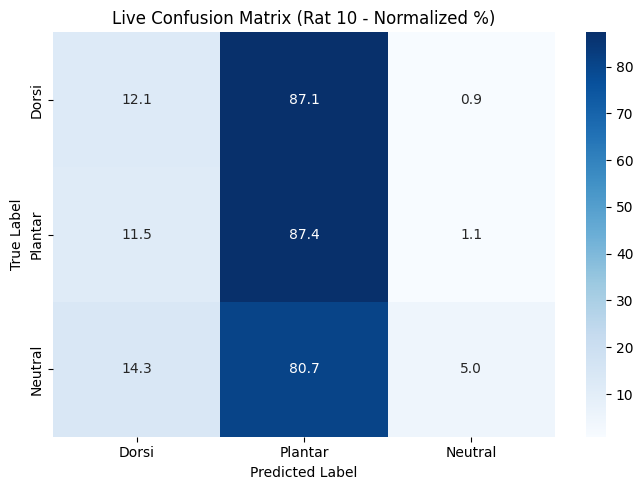

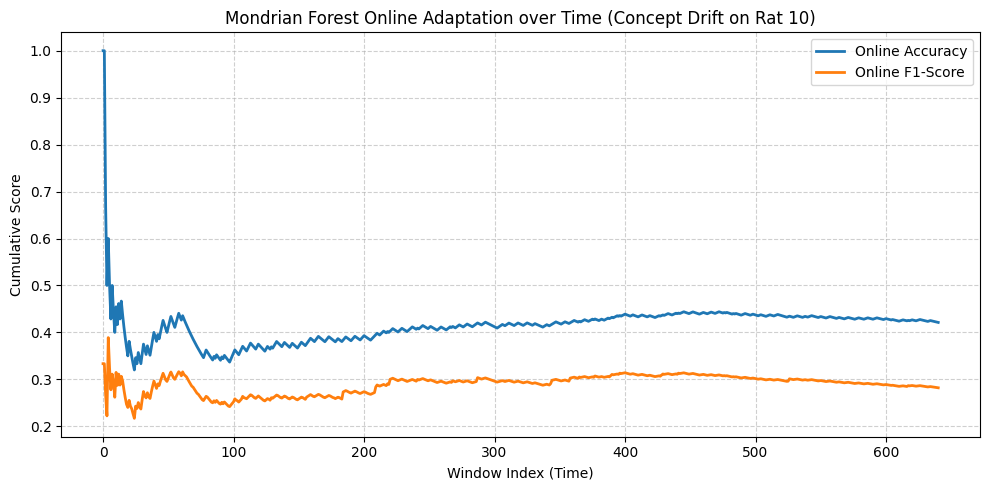

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_live['label'], df_live['pred'])
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(7, 5))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=["Dorsi", "Plantar", "Neutral"], 
            yticklabels=["Dorsi", "Plantar", "Neutral"])
plt.title('Live Confusion Matrix (Rat 10 - Normalized %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df_live['window_index'], df_live['running_accuracy'], label='Online Accuracy', linewidth=2, color='#1f77b4')
plt.plot(df_live['window_index'], df_live['running_f1'], label='Online F1-Score', linewidth=2, color='#ff7f0e')

plt.title('Mondrian Forest Online Adaptation over Time (Concept Drift on Rat 10)')
plt.xlabel('Window Index (Time)')
plt.ylabel('Cumulative Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

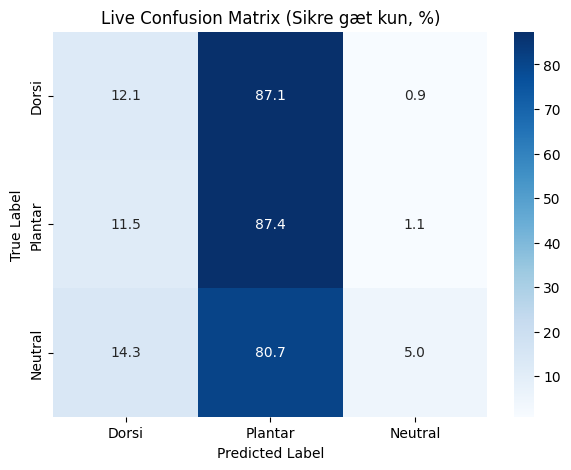

In [9]:
# Beregn CM baseret på de filtrerede data
cm = confusion_matrix(df_filtered['label'], df_filtered['pred'], labels=[0, 1, 2])
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(7, 5))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=["Dorsi", "Plantar", "Neutral"], 
            yticklabels=["Dorsi", "Plantar", "Neutral"])
plt.title('Live Confusion Matrix (Sikre gæt kun, %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

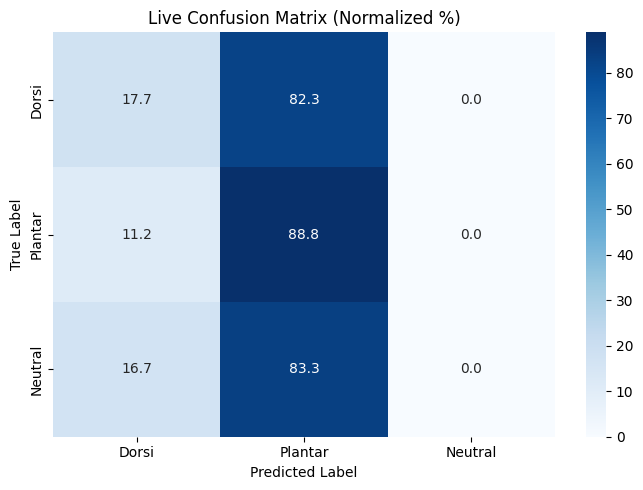

TypeError: not all arguments converted during string formatting

<Figure size 1000x500 with 0 Axes>

In [64]:
cm = confusion_matrix(df['label'], df['pred'])
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(7, 5))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=["Dorsi", "Plantar", "Neutral"], 
            yticklabels=[ "Dorsi", "Plantar","Neutral"])
plt.title('Live Confusion Matrix (Normalized %)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='epoch', y='confidence', data=df[df['epoch'] % 5 == 0])
plt.title('Model Prediction Confidence Distribution over Selected Epochs')
plt.xlabel('Epoch')
plt.ylabel('Max Class Probability (Confidence)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "./dataset_rats_50w"
CLASS_NAMES = {0: "Dorsi (< -2°)", 1: "Plantar (> 2°)", 2: "Neutral (between -2° and 2°)"}

global_counts = {0: 0, 1: 0, 2: 0}

# Samme logik som i streamer.py for at skabe de korrekte vinduer
def get_window_labels(angles_ds, seq_len=16, subsample_rate=8):
    y = np.full(len(angles_ds), 2, dtype=np.int64)  # Default: Neutral
    y[angles_ds > 2.0] = 1   # Plantar
    y[angles_ds < -2.0] = 0  # Dorsi
    
    y_seq = []
    for i in range(seq_len, len(y), subsample_rate):
        window_labels = y[i - seq_len:i]
        counts = np.bincount(window_labels, minlength=3)
        majority = int(np.argmax(counts))
        y_seq.append(majority)
        
    return np.array(y_seq)

for filename in sorted(os.listdir(DATA_DIR)):
    if filename.endswith(".npz"):
        path = os.path.join(DATA_DIR, filename)

        data = np.load(path)
        angles = data["a"]
        
        # Brug majority voting funktionen!
        window_labels = get_window_labels(angles)

        unique, counts = np.unique(window_labels, return_counts=True)
        rat_counts = dict(zip(unique, counts))

        for c in (0, 1, 2):
            rat_counts[c] = rat_counts.get(c, 0)
            global_counts[c] += rat_counts[c] 
            
        total_rat_samples = sum(rat_counts.values())

        print(f"\nFil: {filename} (Total windows: {total_rat_samples})")
        for c_id, name in CLASS_NAMES.items():
            count = rat_counts[c_id]
            pct = (count / total_rat_samples) * 100 if total_rat_samples > 0 else 0
            print(f"  {name:<30}: {count:>6} windows ({pct:>5.2f}%)")

print("\n" + "="*50)
print("=== sum global class balance (WINDOWS) ===")
print("="*50)

total_global_samples = sum(global_counts.values())
for c_id, name in CLASS_NAMES.items():
    count = global_counts[c_id]
    pct = (count / total_global_samples) * 100 if total_global_samples > 0 else 0
    print(f"{name:<32}: {count:>7} windows ({pct:>5.2f}%)")
print(f"total window count : {total_global_samples}")


Fil: rat10.npz (Total windows: 815)
  Dorsi (< -2°)                 :    272 windows (33.37%)
  Plantar (> 2°)                :    314 windows (38.53%)
  Neutral (between -2° and 2°)  :    229 windows (28.10%)

Fil: rat4.npz (Total windows: 911)
  Dorsi (< -2°)                 :    311 windows (34.14%)
  Plantar (> 2°)                :    339 windows (37.21%)
  Neutral (between -2° and 2°)  :    261 windows (28.65%)

Fil: rat5.npz (Total windows: 842)
  Dorsi (< -2°)                 :    305 windows (36.22%)
  Plantar (> 2°)                :    322 windows (38.24%)
  Neutral (between -2° and 2°)  :    215 windows (25.53%)

Fil: rat6.npz (Total windows: 834)
  Dorsi (< -2°)                 :    320 windows (38.37%)
  Plantar (> 2°)                :    322 windows (38.61%)
  Neutral (between -2° and 2°)  :    192 windows (23.02%)

Fil: rat7.npz (Total windows: 903)
  Dorsi (< -2°)                 :    305 windows (33.78%)
  Plantar (> 2°)                :    351 windows (38.87%)
  Neutr

In [11]:
import numpy as np
import os

DATA_DIR = "./splits" 
FILES_TO_CHECK = ["train.npz", "live.npz", "val.npz"] 

print(f"=== Klassefordeling i splits ===")

for filename in FILES_TO_CHECK:
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        data = np.load(path)
        labels = data["y"] 
        
        unique, counts = np.unique(labels, return_counts=True)
        counts_dict = dict(zip(unique, counts))
        
        total = len(labels)
        print(f"\nFil: {filename} (Total: {total})")
        
        # Mapping: 0=Dorsi, 1=Plantar, 2=Neutral
        class_names = {0: "Dorsi", 1: "Plantar", 2: "Neutral"}
        for c_id, name in class_names.items():
            count = counts_dict.get(c_id, 0)
            pct = (count / total) * 100
            print(f"  {name:<8}: {count:>6} samples ({pct:>5.2f}%)")
    else:
        print(f"\nFilen {filename} blev ikke fundet i {DATA_DIR}")

SPLITS_DIR = "./splits"

if os.path.exists(SPLITS_DIR):
    files = sorted(os.listdir(SPLITS_DIR))
    print(f"Indhold af {SPLITS_DIR}:")
    for f in files:
        print(f" - {f}")
else:
    print(f"Mappen {SPLITS_DIR} blev ikke fundet! Tjek stien.")

=== Klassefordeling i splits ===

Fil: train.npz (Total: 539)
  Dorsi   :    210 samples (38.96%)
  Plantar :    210 samples (38.96%)
  Neutral :    119 samples (22.08%)

Fil: live.npz (Total: 641)
  Dorsi   :    232 samples (36.19%)
  Plantar :    269 samples (41.97%)
  Neutral :    140 samples (21.84%)

Fil: val.npz (Total: 96)
  Dorsi   :     30 samples (31.25%)
  Plantar :     50 samples (52.08%)
  Neutral :     16 samples (16.67%)
Indhold af ./splits:
 - live.npz
 - train.npz
 - val.npz
